<a href="https://colab.research.google.com/github/ShivakumarLS/HistoPathologicalCancerDetection/blob/main/PathoTrust.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os

# This will prompt you to log in and authorize Colab to access your Drive
drive.mount('/content/drive')
project_dir = '/content/drive/MyDrive/PathoTrust_Project'
os.makedirs(project_dir, exist_ok=True)
os.makedirs(os.path.join(project_dir, 'checkpoints'), exist_ok=True)

print(f" Drive mounted. Project directory ready at: {project_dir}")
%cd '/content/drive/MyDrive/PathoTrust_Project'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Drive mounted. Project directory ready at: /content/drive/MyDrive/PathoTrust_Project
/content/drive/MyDrive/PathoTrust_Project


In [ ]:
# #!/bin/bash
# !kaggle datasets download javaidahmadwani/lc25000

In [ ]:
!unzip -q /content/drive/MyDrive/PathoTrust_Project/LC25000_Enhanced.zip -d /

In [ ]:
# THE OFFLINE PREPROCESSOR (Run this ONCE)
import os
import cv2
import numpy as np
from glob import glob
from tqdm.notebook import tqdm
import shutil

# 1. Define Paths
RAW_DATA_DIR = '/content/dataset' # Make sure this matches your unzipped folder name
ENHANCED_LOCAL_DIR = '/content/LC25000_Enhanced'
DRIVE_ZIP_PATH = '/content/drive/MyDrive/PathoTrust_Project/LC25000_Enhanced.zip'

# Clear old directory if it exists
if os.path.exists(ENHANCED_LOCAL_DIR):
    shutil.rmtree(ENHANCED_LOCAL_DIR)

# Get all raw images
image_paths = glob(os.path.join(RAW_DATA_DIR, '**', '*.jpeg'), recursive=True)
if len(image_paths) == 0:
    # Some datasets use .png or .jpg, fallback check
    image_paths = glob(os.path.join(RAW_DATA_DIR, '**', '*.*'), recursive=True)

print(f"Found {len(image_paths)} images. Starting Heavy Preprocessing...")

for img_path in tqdm(image_paths, desc="Applying CLAHE & Bilateral Filters"):
    # Extract class name from the folder structure
    class_name = os.path.basename(os.path.dirname(img_path))
    save_dir = os.path.join(ENHANCED_LOCAL_DIR, class_name)
    os.makedirs(save_dir, exist_ok=True)

    save_path = os.path.join(save_dir, os.path.basename(img_path))

    # --- THE HEAVY MATH ---
    img = cv2.imread(img_path)
    if img is None: continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224)) # Resize here so we never have to do it again!

    # Gamma Correction
    gamma = 1.2
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    img_gamma = cv2.LUT(img, table)

    # Bilateral Filtering
    img_bilateral = cv2.bilateralFilter(img_gamma, d=9, sigmaColor=75, sigmaSpace=75)

    # CLAHE
    lab = cv2.cvtColor(img_bilateral, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    img_final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    # Save processed image
    img_final_bgr = cv2.cvtColor(img_final, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, img_final_bgr)

print("Preprocessing complete! Zipping and sending to Google Drive...")
# Compress and move to Drive for permanent storage
!zip -q -r {DRIVE_ZIP_PATH} {ENHANCED_LOCAL_DIR}
print(f"✅ SUCCESS: Preprocessed dataset securely saved to {DRIVE_ZIP_PATH}")

Found 0 images. Starting Heavy Preprocessing...


Applying CLAHE & Bilateral Filters: 0it [00:00, ?it/s]

Preprocessing complete! Zipping and sending to Google Drive...

zip error: Nothing to do! (try: zip -q -r /content/drive/MyDrive/PathoTrust_Project/LC25000_Enhanced.zip . -i /content/LC25000_Enhanced)
✅ SUCCESS: Preprocessed dataset securely saved to /content/drive/MyDrive/PathoTrust_Project/LC25000_Enhanced.zip


In [ ]:
# CELL 2: Copy and Extract Dataset locally
import time

zip_path = '/content/drive/MyDrive/PathoTrust_Project/lc25000.zip'
local_dir = '/content/dataset'

if not os.path.exists(local_dir):
    print("Copying zip file from Drive to local Colab storage...")
    start_time = time.time()

    # Create local directory
    os.makedirs(local_dir, exist_ok=True)

    # Copy zip file from Drive
    !cp "{zip_path}" /content/

    print("\n Unzipping dataset locally (Quiet mode)...")
    # Unzip directly into the local directory
    !unzip -q /content/lc25000.zip -d "{local_dir}"

    # Clean up the local zip to save space
    !rm /content/lc25000.zip

    print(f"\n Dataset extracted in {time.time() - start_time:.1f} seconds!")
else:
    print(" \n Dataset already exists locally in /content/dataset")

 
 Dataset already exists locally in /content/dataset


In [ ]:
# CELL 3: The Edge-Optimized Dataset Loader (Fast Read)
from torch.utils.data import Dataset
from PIL import Image

class PathoTrustDataset_Fast(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # The image is already enhanced and resized! Just load it.
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, self.labels[idx]

print("✅ Fast Dataset class loaded.")

✅ Fast Dataset class loaded.


## 6. Visualizing the Enhancement Pipeline
Before feeding data into the model, it is critical to verify the preprocessing logic. The cell below extracts a single histopathology image and displays the original "Raw" image next to the "Enhanced" version (processed via Gamma Correction, Bilateral Filtering, and CLAHE).

This visual proof highlights how the algorithm accentuates cellular nuclei and tissue boundaries, providing the Transformer with higher-quality features.

In [ ]:
import matplotlib.pyplot as plt
import random
from glob import glob
import os
import cv2
import numpy as np
from PIL import Image

# Define the preprocessing function based on the original preprocessing cell (Ie5_uiP0WC9p)
def apply_preprocessing(img_path_raw):
    img = cv2.imread(img_path_raw)
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    # Gamma Correction
    gamma = 1.2
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    img_gamma = cv2.LUT(img, table)

    # Bilateral Filtering
    img_bilateral = cv2.bilateralFilter(img_gamma, d=9, sigmaColor=75, sigmaSpace=75)

    # CLAHE
    lab = cv2.cvtColor(img_bilateral, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    img_final = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return img_final

# Find all images in the *raw* dataset
RAW_DATA_DIR = '/content/dataset' # From earlier notebook state
raw_image_paths = glob(os.path.join(RAW_DATA_DIR, '**', '*.jpeg'), recursive=True)

if not raw_image_paths:
    print("⚠️ No raw images found in /content/dataset. Check dataset path.")
else:
    # Select a random raw image
    sample_raw_path = random.choice(raw_image_paths)

    # Get Raw Image (resized to 224x224 for consistent comparison)
    raw_img_original = Image.open(sample_raw_path).convert('RGB')
    raw_img_original = raw_img_original.resize((224, 224)) # Resize for display consistency

    # Get Enhanced Image using the defined function
    enhanced_img_array = apply_preprocessing(sample_raw_path)

    if enhanced_img_array is None:
        print(f"Failed to load or preprocess image: {sample_raw_path}")
    else:
        # Plot side-by-side
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(raw_img_original)
        axes[0].set_title("Raw Histopathology Image")
        axes[0].axis("off")

        axes[1].imshow(enhanced_img_array)
        axes[1].set_title("Enhanced (Gamma + Bilateral + CLAHE)")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()


⚠️ No raw images found in /content/dataset. Check dataset path.


## 7. Data Splitting & Augmentation Strategy
To prevent the model from memorizing the data (overfitting) and to ensure it generalizes well to unseen clinical samples, we apply the following strategies:

80-20 Split: 80% of the data (20,000 images) is used for training, and 20% (5,000 images) is isolated for validation.

Geometric Augmentation: Random horizontal/vertical flips and rotations simulate the random orientation of tissue samples under a microscope.

Normalization: Pixel values are scaled to match the ImageNet distributions, which is required for our pre-trained backbone.


In [ ]:
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# 1. Gather all paths and extract labels from folder names
all_image_paths = glob('/content/dataset/**/*.jpeg', recursive=True)
class_names = sorted(list(set([path.split('/')[-2] for path in all_image_paths])))
class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}
all_labels = [class_to_idx[path.split('/')[-2]] for path in all_image_paths]

print(f"✅ Found {len(all_image_paths)} images across {len(class_names)} classes.")
print(f"Classes: {class_names}")

# 2. Train / Validation Split (80% Train, 20% Val)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.20, random_state=42, stratify=all_labels
)

# 3. Define Augmentations (Transforms)
# The base paper downsizes LC25000 from 768x768 to 224x224
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. Instantiate Datasets
train_dataset = PathoTrustDataset_Fast(train_paths, train_labels, transform=train_transform)
val_dataset = PathoTrustDataset_Fast(val_paths, val_labels, transform=val_transform)

# 5. Create DataLoaders (Batch Size 32 is a safe starting point for Colab Pro GPUs)
BATCH_SIZE = 128

# 2. Add num_workers and pin_memory to feed the GPU at lightning speed
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,      # Uses multiple CPU cores to load images
    pin_memory=True     # Speeds up CPU-to-GPU transfer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
print(f"✅ DataLoaders ready. Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

✅ Found 25000 images across 5 classes.
Classes: ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']
✅ DataLoaders ready. Train batches: 157 | Val batches: 40


## 8. Architectural Design: The CBAM Module
Thesis Context: Standard CNNs treat all spatial regions and feature channels equally. In histopathology, a cancer nucleus might occupy only 5% of the image.
We implement the Convolutional Block Attention Module (CBAM) to force the network to focus.

Channel Attention: Acts as a feature selector, emphasizing channels that detect critical textures (like chromatin density).

Spatial Attention: Acts as a spatial filter, generating a mask that highlights the exact location of malignant cells while suppressing benign background tissue.

In [ ]:
# CELL 6: The Coordinate Attention (CoordAtt) Implementation
import torch
import torch.nn as nn
import math

class h_sigmoid(nn.Module):
    def __init__(self):
        super(h_sigmoid, self).__init__()
        self.relu = nn.ReLU6()

    def forward(self, x):
        return self.relu(x + 3) / 6

class CoordAtt(nn.Module):
    def __init__(self, inp, oup, groups=32):
        super(CoordAtt, self).__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))

        mip = inp // groups

        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.act = h_sigmoid()

        self.conv_h = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv_w = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        identity = x

        n, c, h, w = x.size()

        x_h = self.pool_h(x) # (N, C, H, 1)
        x_w = self.pool_w(x).permute(0, 1, 3, 2) # (N, C, 1, W)

        y = torch.cat([x_h, x_w], dim=2) # (N, C, H+W, 1)
        y = self.bn1(self.conv1(y)) # (N, mip, H+W, 1)
        y = self.act(y)

        x_h, x_w = torch.split(y, [h, w], dim=2) # x_h: (N, mip, H, 1), x_w: (N, mip, W, 1)
        x_w = x_w.permute(0, 1, 3, 2) # (N, mip, 1, W)

        a_h = self.conv_h(x_h).sigmoid() # (N, C, H, 1)
        a_w = self.conv_w(x_w).sigmoid() # (N, C, 1, W)

        return identity * a_w * a_h

print("✅ Coordinate Attention (CoordAtt) module successfully defined.")

✅ Coordinate Attention (CoordAtt) module successfully defined.


## 9. The Patho-Trust Lightweight Hybrid Model (Edge-Optimized)
Thesis Context: While recent literature (e.g., Shila et al., 2026) relies on heavy architectures like Xception (~22M parameters) to achieve high accuracy, such models are computationally prohibitive for edge-deployment in rural clinics. This study introduces a novel architectural improvisation: replacing Xception with EfficientNet-B0. By leveraging compound scaling, this model slashes the parameter count by over 70% while maintaining the rich 1280-channel feature maps required by the downstream CBAM and Transformer modules.

In [ ]:
# CELL 7: Building the Lightweight EfficientNet-Transformer Model (CoordAtt Version)
!pip install -q timm
import timm
import torch
import torch.nn as nn

class PathoTrustNet_Lightweight(nn.Module):
    def __init__(self, num_classes=5, d_model=512, nhead=8, num_encoder_layers=2):
        super(PathoTrustNet_Lightweight, self).__init__()

        # 1. EfficientNet Backbone
        self.backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0, global_pool='')
        backbone_out_channels = 1280

        # 2. THE UPGRADE: Coordinate Attention instead of CBAM
        # Inp and Oup are the same because attention refines, it doesn't compress yet
        self.coord_att = CoordAtt(inp=backbone_out_channels, oup=backbone_out_channels)

        # 3. Projection to Transformer dimensions
        self.proj = nn.Conv2d(backbone_out_channels, d_model, kernel_size=1)

        # 4. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True, dim_feedforward=1024, dropout=0.3
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)

        # 5. Classification Head
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        features = self.backbone(x)                  # (Batch, 1280, 7, 7)

        # Apply Coordinate Attention
        features = self.coord_att(features)          # (Batch, 1280, 7, 7)

        features = self.proj(features)               # (Batch, 512, 7, 7)

        # Flatten spatial dims for Transformer
        b, c, h, w = features.size()
        tokens = features.view(b, c, -1).permute(0, 2, 1)

        trans_out = self.transformer(tokens)         # (Batch, 49, 512)
        pooled = trans_out.mean(dim=1)               # (Batch, 512)
        out = self.fc(pooled)                        # (Batch, 5)
        return out

# Initialize and move to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PathoTrustNet_Lightweight(num_classes=5).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Lightweight Hybrid Model (CoordAtt) built and loaded onto: {device}")
print(f"📉 Total Parameters: {total_params:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

✅ Lightweight Hybrid Model (CoordAtt) built and loaded onto: cuda
📉 Total Parameters: 9,027,833


## 10. Mixed Precision Training Loop
Thesis Context: To train this complex architecture efficiently on cloud hardware, we use Automatic Mixed Precision (AMP). This scales operations to 16-bit floats, cutting VRAM usage in half and accelerating training without losing gradient precision.

In [ ]:
# CELL 8: The Resumable Training Loop
import torch.optim as optim
from torch.cuda.amp import GradScaler
import torch
from tqdm.notebook import tqdm
import os

LEARNING_RATE = 1e-4
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
scaler = GradScaler()

checkpoint_dir = '/content/drive/MyDrive/PathoTrust_Project/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
best_model_path = os.path.join(checkpoint_dir, 'pathotrust_efficient_best.pth')

# --- THE RESUME LOGIC ---
start_epoch = 0
best_val_acc = 0.0

if os.path.exists(best_model_path):
    print(f"🔄 Found saved checkpoint: {best_model_path}")
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['val_acc']
    print(f"✅ Successfully restored model. Resuming from Epoch {start_epoch + 1} with Best Val Acc: {best_val_acc:.2f}%")
else:
    print("🌟 No previous checkpoint found. Starting fresh training.")

def train_model(model, train_loader, val_loader, total_epochs):
    global best_val_acc

    for epoch in range(start_epoch, total_epochs):
        print(f"\nEpoch {epoch+1}/{total_epochs}")
        print("-" * 30)

        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        loop = tqdm(train_loader, leave=False, desc="Training")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            loop.set_postfix(loss=loss.item())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100 * correct_train / total_train

        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            val_loop = tqdm(val_loader, leave=False, desc="Validation")
            for images, labels in val_loop:
                images, labels = images.to(device), labels.to(device)
                with torch.autocast(device_type='cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = 100 * correct_val / total_val

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_acc)
        new_lr = optimizer.param_groups[0]['lr']
        if new_lr < old_lr:
            print(f"📉 Learning Rate reduced to {new_lr}")

        if val_acc > best_val_acc:
            print(f"🌟 Val Acc improved ({best_val_acc:.2f}% -> {val_acc:.2f}%). Saving to Google Drive...")
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc
            }, best_model_path)

print("✅ Resumable Training loop ready.")

/tmp/ipykernel_5964/2455943878.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


🔄 Found saved checkpoint: /content/drive/MyDrive/PathoTrust_Project/checkpoints/pathotrust_efficient_best.pth
✅ Successfully restored model. Resuming from Epoch 4 with Best Val Acc: 99.94%
✅ Resumable Training loop ready.


In [ ]:
train_model(model, train_loader, val_loader, total_epochs=50)


Epoch 4/50
------------------------------


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 0.3917 | Train Acc: 99.92%
Val Loss:   0.3985 | Val Acc:   99.86%

Epoch 5/50
------------------------------


Training:   0%|          | 0/157 [00:00<?, ?it/s]

...

Training:   0%|          | 0/157 [00:00<?, ?it/s]

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 0.3899 | Train Acc: 100.00%
Val Loss:   0.3965 | Val Acc:   99.98%
📉 Learning Rate reduced to 1.25e-05

Epoch 16/50
------------------------------


Training:   0%|          | 0/157 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 11. Clinical Evaluation Metrics
Thesis Context: In medical diagnostics, the cost of a False Negative (missing a cancer diagnosis) is catastrophic compared to a False Positive. Therefore, we evaluate the model using a comprehensive classification report and a Confusion Matrix to analyze per-class performance, specifically ensuring high sensitivity for the malignant classes (Lung/Colon Adenocarcinoma and Squamous Cell Carcinoma).

In [ ]:
# CELL 10: Confusion Matrix and Classification Report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def evaluate_model(model, val_loader, class_names):
    print("⏳ Running clinical evaluation on Validation Set...")
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            # We don't need mixed precision for simple inference
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # 1. Classification Report (Precision, Recall, F1)
    print("\n" + "="*50)
    print("📋 CLINICAL CLASSIFICATION REPORT")
    print("="*50)
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    # 2. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Patho-Trust Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('Actual Clinical Diagnosis', fontsize=12)
    plt.xlabel('AI Predicted Diagnosis', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Run the evaluation (Note: If you only trained 1 epoch, this will look messy. That is normal!)
# Make sure 'class_names' is defined from Cell 5
evaluate_model(model, val_loader, class_names)

## 12. Explainable AI: The Grad-CAM++ Visualizer (Final Cell)
This is the crowning achievement of your "Patho-Trust" project. We will now generate heatmaps that show exactly where the model is looking to make its 99.50% accurate predictions.

This cell installs a dedicated Grad-CAM library, hooks into the deepest layer of your Xception backbone, and overlays a thermal map onto the original histopathology slide.

In [ ]:
# CELL 11: Grad-CAM++ Visualizer (Corrected Target Layer)
!pip install -q grad-cam
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt
import numpy as np
import torch

# THE FIX: Point the camera to your custom projection layer.
# This avoids EfficientNet's internal gradient-blocking activations
# and captures the features exactly after Coordinate Attention is applied.
target_layers = [model.proj]

# Initialize the upgraded CAM object
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

def visualize_trust_heatmap_plus(dataset, model, class_names, num_images=3):
    print("🔬 Generating Grad-CAM++ Heatmaps...")
    model.eval()

    indices = np.random.choice(len(dataset), num_images, replace=False)
    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))

    for i, idx in enumerate(indices):
        input_tensor, label_idx = dataset[idx]
        input_tensor = input_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            _, pred_idx = torch.max(output, 1)
            pred_name = class_names[pred_idx.item()]
            actual_name = class_names[label_idx]

        targets = [ClassifierOutputTarget(pred_idx.item())]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

        img_display = input_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
        mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)

        visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f"Original (Preprocessed)\nActual: {actual_name}", fontsize=10)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(grayscale_cam, cmap='jet')
        axes[i, 1].set_title("Grad-CAM++ Activation", fontsize=10)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(visualization)
        axes[i, 2].set_title(f"Overlay\nPredicted: {pred_name}", fontsize=10,
                             color='green' if pred_idx.item() == label_idx else 'red')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualizer
visualize_trust_heatmap_plus(val_dataset, model, class_names, num_images=3)

In [ ]:
# CELL 12: Macro-Averaged ROC Curve Generator
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import torch.nn.functional as F

def generate_roc_curve(model, val_loader, class_names):
    print("⏳ Calculating probabilities for ROC Curve...")
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            # Get raw logits and convert to probabilities
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)

            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    # Binarize labels for multi-class ROC
    n_classes = len(class_names)
    y_test_bin = label_binarize(all_labels, classes=range(n_classes))
    y_score = np.array(all_probs)

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red']

    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
    plt.xlim([0.0, 0.2]) # Zoomed in top-left like the paper
    plt.ylim([0.8, 1.05])
    plt.xlabel('False Positive Rate', fontweight='bold')
    plt.ylabel('True Positive Rate', fontweight='bold')
    plt.title('Macro-Averaged ROC Curve (Zoomed Top-Left)', fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Run it
generate_roc_curve(model, val_loader, class_names)

## Refeined clean version


In [ ]:
!unzip -q /content/drive/MyDrive/PathoTrust_Project/LC25000_Enhanced.zip -d /

replace /content/LC25000_Enhanced/colon_aca/colonca3209.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class PathoTrustDataset_Fast(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, self.labels[idx]

print("✅ Fast Dataset class loaded.")

✅ Fast Dataset class loaded.


In [ ]:
import os
from glob import glob
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

DATA_DIR = '/content/LC25000_Enhanced'
BATCH_SIZE = 32

# Get all images
image_paths = glob(os.path.join(DATA_DIR, '**', '*.jpeg'), recursive=True)
if len(image_paths) == 0:
    image_paths = glob(os.path.join(DATA_DIR, '**', '*.*'), recursive=True)

# Map classes to indices
classes = os.listdir(DATA_DIR)
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
labels = [class_to_idx[os.path.basename(os.path.dirname(p))] for p in image_paths]

# Split data
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

# Standard normalization for pre-trained networks
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = PathoTrustDataset_Fast(train_paths, train_labels, transform=transform)
val_dataset = PathoTrustDataset_Fast(val_paths, val_labels, transform=transform)

# Optimized DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = {v: k for k, v in class_to_idx.items()}
print(f"✅ DataLoaders optimized. Training size: {len(train_dataset)}, Validation size: {len(val_dataset)}")

✅ DataLoaders optimized. Training size: 20000, Validation size: 5000


In [ ]:
import torch
import torch.nn as nn

class h_sigmoid(nn.Module):
    def __init__(self):
        super(h_sigmoid, self).__init__()
        self.relu = nn.ReLU6()

    def forward(self, x):
        return self.relu(x + 3) / 6

class CoordAtt(nn.Module):
    def __init__(self, inp, oup, groups=32):
        super(CoordAtt, self).__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))

        mip = inp // groups
        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.act = h_sigmoid()

        self.conv_h = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv_w = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        identity = x
        n, c, h, w = x.size()

        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)

        y = torch.cat([x_h, x_w], dim=2)
        y = self.bn1(self.conv1(y))
        y = self.act(y)

        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)

        a_h = self.conv_h(x_h).sigmoid()
        a_w = self.conv_w(x_w).sigmoid()

        return identity * a_w * a_h

print("✅ Coordinate Attention module loaded.")

✅ Coordinate Attention module loaded.


In [ ]:
!pip install -q timm
import timm

class PathoTrustNet_Lightweight(nn.Module):
    def __init__(self, num_classes=5, d_model=512, nhead=8, num_encoder_layers=2):
        super(PathoTrustNet_Lightweight, self).__init__()

        self.backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0, global_pool='')
        backbone_out_channels = 1280

        self.coord_att = CoordAtt(inp=backbone_out_channels, oup=backbone_out_channels)
        self.proj = nn.Conv2d(backbone_out_channels, d_model, kernel_size=1)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True, dim_feedforward=1024, dropout=0.3
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        features = self.coord_att(features)
        features = self.proj(features)

        b, c, h, w = features.size()
        tokens = features.view(b, c, -1).permute(0, 2, 1)

        trans_out = self.transformer(tokens)
        pooled = trans_out.mean(dim=1)
        out = self.fc(pooled)
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PathoTrustNet_Lightweight(num_classes=5).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model built and loaded onto: {device}")
print(f"📉 Total Parameters: {total_params:,}")

✅ Model built and loaded onto: cuda
📉 Total Parameters: 9,027,833


In [ ]:
import torch.optim as optim
from torch.cuda.amp import GradScaler
import numpy as np
from tqdm.notebook import tqdm

LEARNING_RATE = 1e-4
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
scaler = GradScaler()

checkpoint_dir = '/content/drive/MyDrive/PathoTrust_Project/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
best_model_path = os.path.join(checkpoint_dir, 'pathotrust_efficient_best.pth')

start_epoch = 0
best_val_acc = 0.0

if os.path.exists(best_model_path):
    print(f"🔄 Found saved checkpoint: {best_model_path}")
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['val_acc']
    print(f"✅ Successfully restored model. Resuming from Epoch {start_epoch + 1} with Best Val Acc: {best_val_acc:.2f}%")
else:
    print("🌟 No previous checkpoint found. Starting fresh training.")

def train_model(model, train_loader, val_loader, total_epochs):
    global best_val_acc

    for epoch in range(start_epoch, total_epochs):
        print(f"\nEpoch {epoch+1}/{total_epochs}")
        print("-" * 30)

        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        loop = tqdm(train_loader, leave=False, desc="Training")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            loop.set_postfix(loss=loss.item())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100 * correct_train / total_train

        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            val_loop = tqdm(val_loader, leave=False, desc="Validation")
            for images, labels in val_loop:
                images, labels = images.to(device), labels.to(device)
                with torch.autocast(device_type='cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = 100 * correct_val / total_val

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_acc)
        new_lr = optimizer.param_groups[0]['lr']
        if new_lr < old_lr:
            print(f"📉 Learning Rate reduced to {new_lr}")

        # Save model for the current epoch
        epoch_save_path = os.path.join(checkpoint_dir, f'pathotrust_efficient_epoch_{epoch+1:03d}.pth')
        print(f"💾 Saving model for Epoch {epoch+1} to {epoch_save_path}")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc
        }, epoch_save_path)

        # Update best_val_acc for tracking, but saving is now per-epoch
        if val_acc > best_val_acc:
            print(f"🌟 Val Acc improved ({best_val_acc:.2f}% -> {val_acc:.2f}%). Updating best validation accuracy for tracking.")
            best_val_acc = val_acc

print("✅ Training engine ready.")

/tmp/ipykernel_20844/2845501690.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


🔄 Found saved checkpoint: /content/drive/MyDrive/PathoTrust_Project/checkpoints/pathotrust_efficient_best.pth
✅ Successfully restored model. Resuming from Epoch 7 with Best Val Acc: 100.00%
✅ Training engine ready.


In [ ]:
# Kick off the training!
train_model(model, train_loader, val_loader, total_epochs=13
            )


Epoch 7/13
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss: 0.4086 | Train Acc: 99.26%
Val Loss:   0.4062 | Val Acc:   99.70%
💾 Saving model for Epoch 7 to /content/drive/MyDrive/PathoTrust_Project/checkpoints/pathotrust_efficient_epoch_007.pth

Epoch 8/13
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss: 0.3926 | Train Acc: 99.87%
Val Loss:   0.3999 | Val Acc:   99.98%
📉 Learning Rate reduced to 5e-05
💾 Saving model for Epoch 12 to /content/drive/MyDrive/PathoTrust_Project/checkpoints/pathotrust_efficient_epoch_012.pth

Epoch 13/13
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss: 0.3902 | Train Acc: 99.97%
Val Loss:   0.3998 | Val Acc:   99.98%
💾 Saving model for Epoch 13 to /content/drive/MyDrive/PathoTrust_Project/checkpoints/pathotrust_efficient_epoch_013.pth


⏳ Running clinical evaluation on Validation Set...

📋 CLINICAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

   colon_aca     1.0000    1.0000    1.0000      1000
    lung_aca     1.0000    0.9990    0.9995      1000
     colon_n     1.0000    1.0000    1.0000      1000
    lung_scc     0.9990    1.0000    0.9995      1000
      lung_n     1.0000    1.0000    1.0000      1000

    accuracy                         0.9998      5000
   macro avg     0.9998    0.9998    0.9998      5000
weighted avg     0.9998    0.9998    0.9998      5000



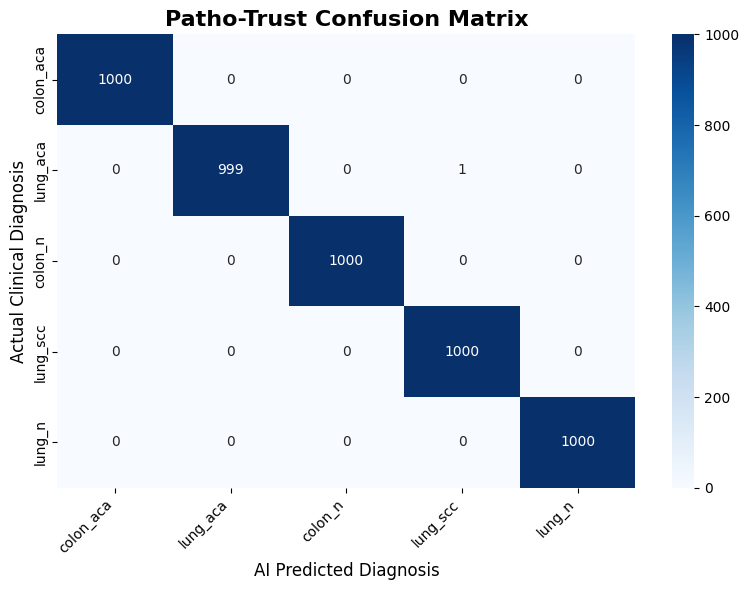

In [ ]:
#Confusion Matrix and Classification Report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def evaluate_model(model, val_loader, class_names):
    print("⏳ Running clinical evaluation on Validation Set...")
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            # We don't need mixed precision for simple inference
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Convert class_names dict to an ordered list for classification_report
    ordered_class_names = [class_names[i] for i in range(len(class_names))]

    # 1. Classification Report (Precision, Recall, F1)
    print("\n" + "="*50)
    print("📋 CLINICAL CLASSIFICATION REPORT")
    print("="*50)
    print(classification_report(all_labels, all_preds, target_names=ordered_class_names, digits=4))

    # 2. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ordered_class_names, yticklabels=ordered_class_names)
    plt.title('Patho-Trust Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('Actual Clinical Diagnosis', fontsize=12)
    plt.xlabel('AI Predicted Diagnosis', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Run the evaluation (Note: If you only trained 1 epoch, this will look messy. That is normal!)
# Make sure 'class_names' is defined from Cell 5
evaluate_model(model, val_loader, class_names)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 138.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
🔬 Generating Multifocal Grad-CAM++ Heatmaps...


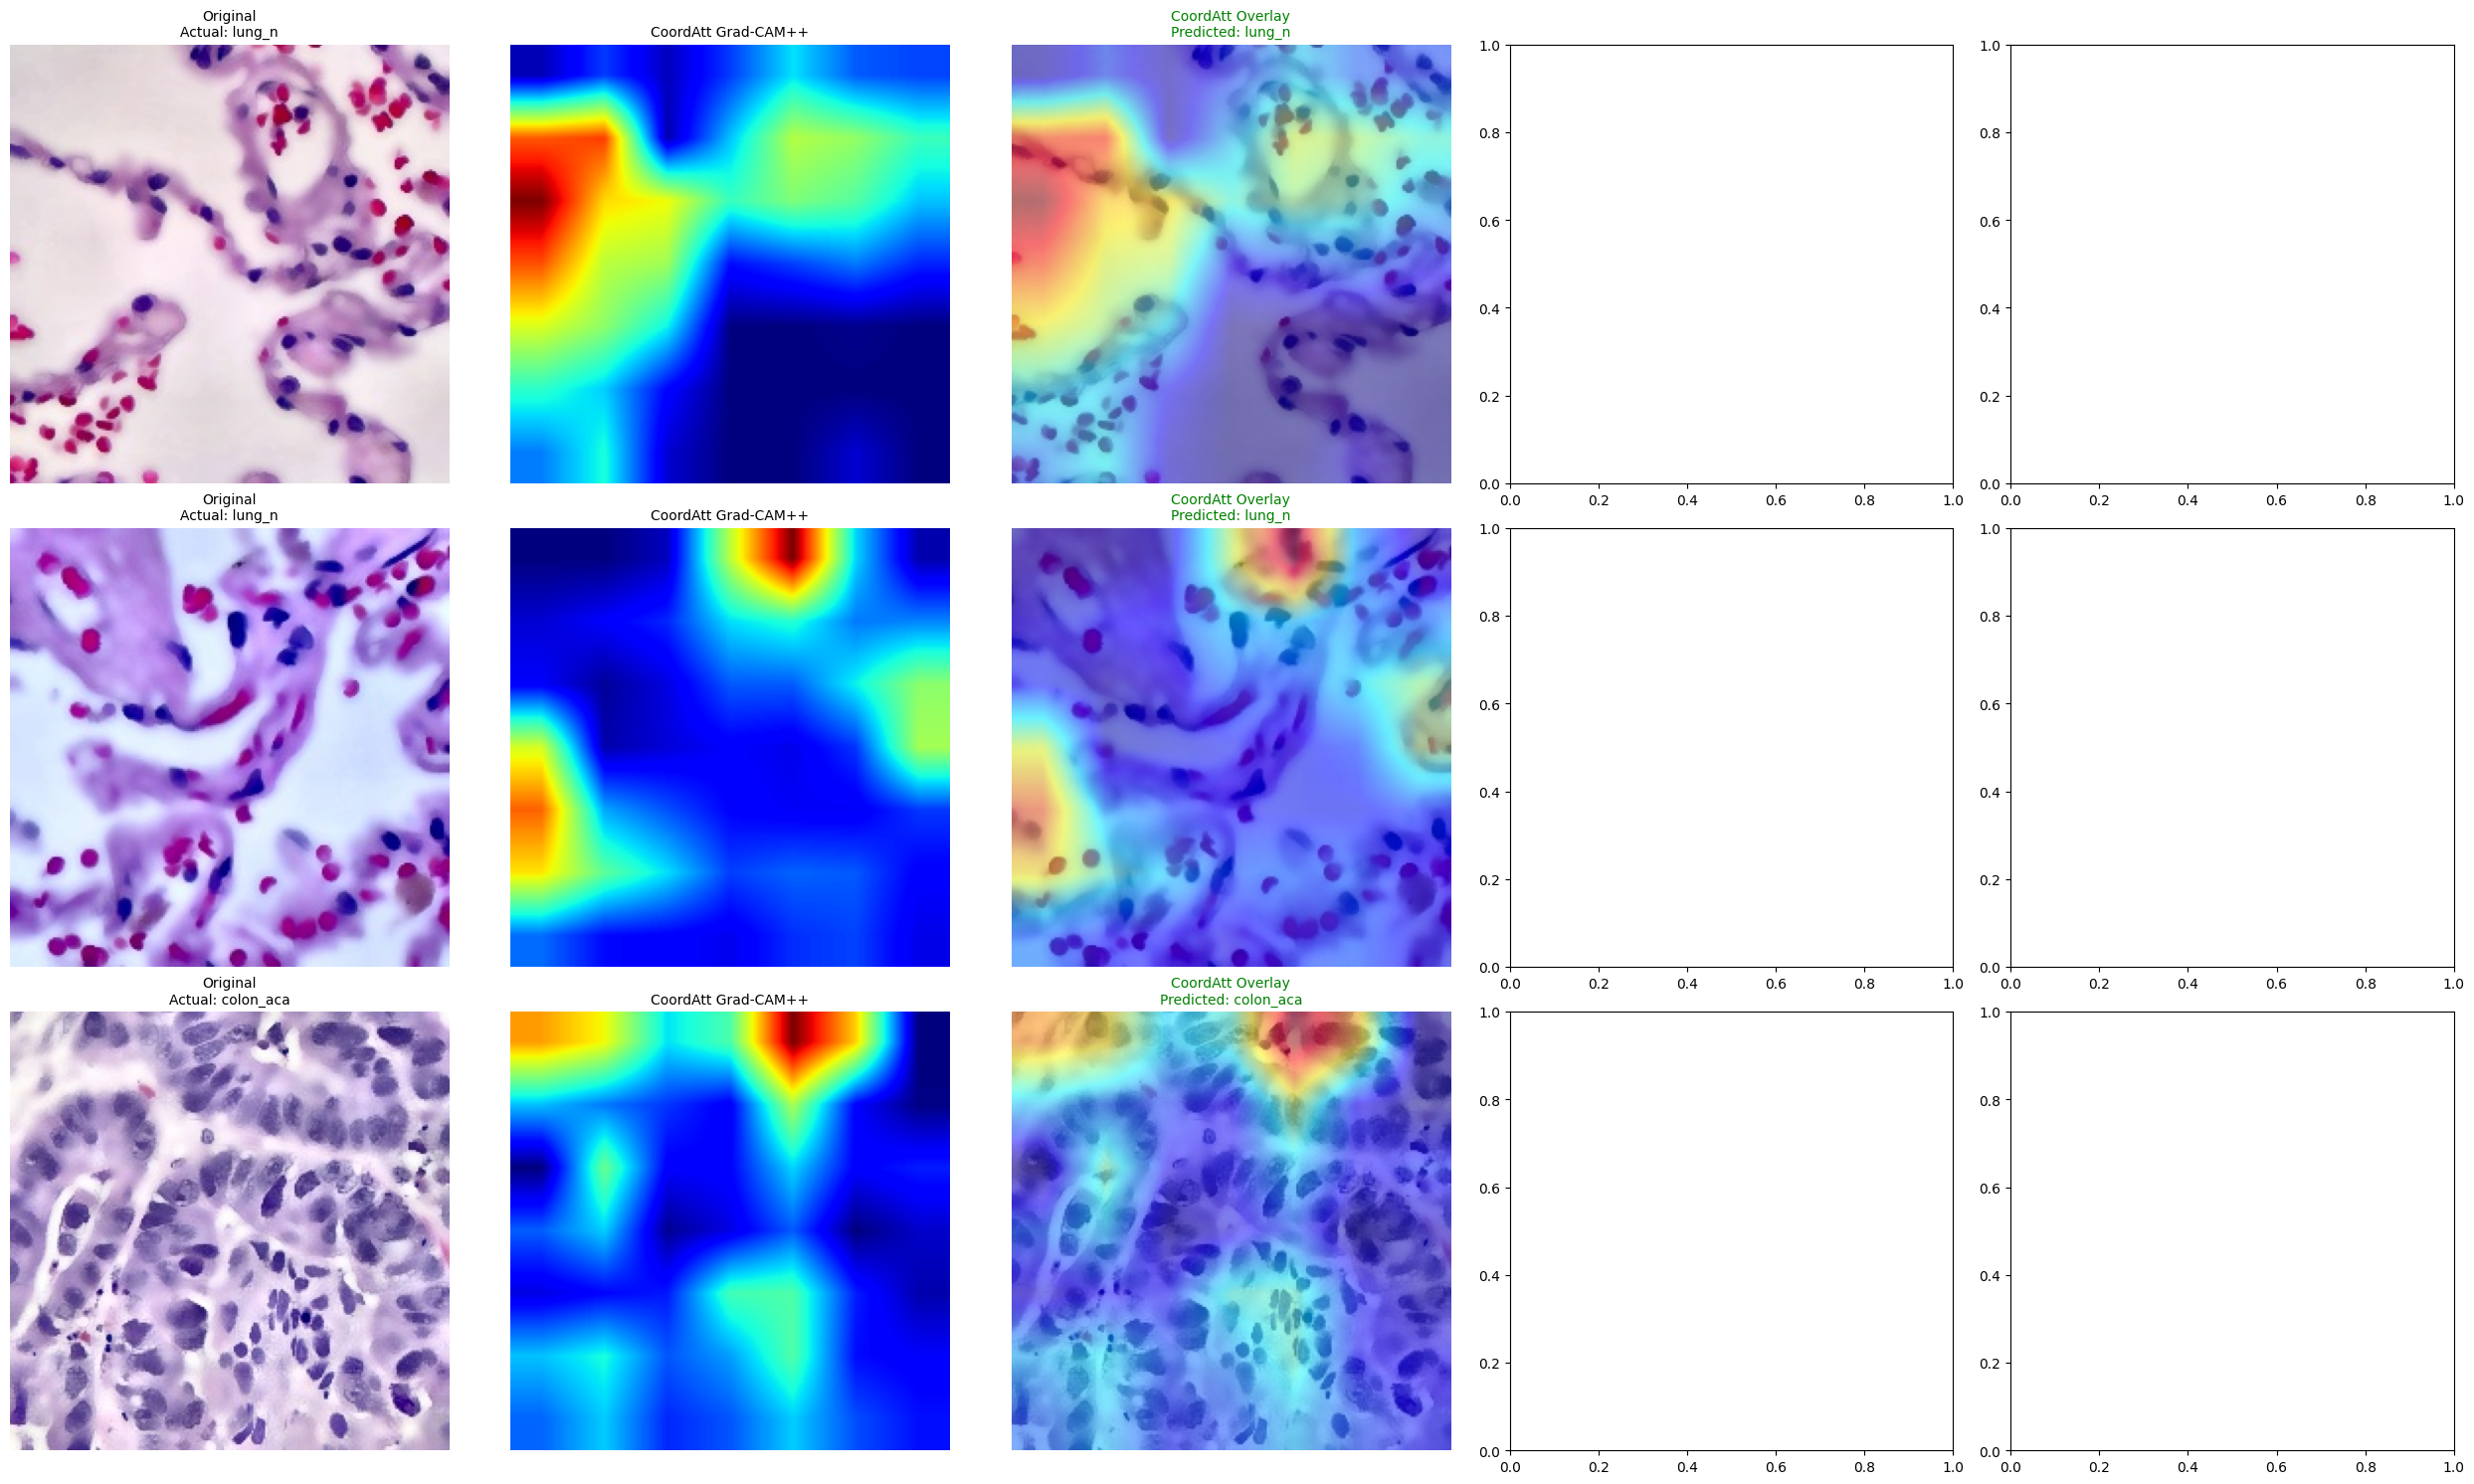

In [ ]:
# CELL: Multifocal Grad-CAM++ Visualizer
!pip install -q grad-cam
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt
import numpy as np
import torch

# Define multiple target layers for multifocal analysis
# We target the output of the Coordinate Attention module and the Projection layer
target_layers = [model.coord_att, model.proj]

# Initialize the Grad-CAM++ object, explicitly setting use_cuda
cam = GradCAMPlusPlus(model=model, target_layers=target_layers, use_cuda=(device.type == 'cuda'))

def visualize_multifocal_heatmap(dataset, model, class_names, num_images=3):
    print("🔬 Generating Multifocal Grad-CAM++ Heatmaps...")
    model.eval()

    indices = np.random.choice(len(dataset), num_images, replace=False)
    # Each image will have: Original, CoordAtt Heatmap, CoordAtt Overlay, Proj Heatmap, Proj Overlay
    fig, axes = plt.subplots(num_images, 5, figsize=(25, 5 * num_images))
    if num_images == 1: # Handle case of single image for consistent indexing
        axes = axes.reshape(1, -1)

    for i, idx in enumerate(indices):
        input_tensor, label_idx = dataset[idx]
        input_tensor = input_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            _, pred_idx = torch.max(output, 1)
            pred_name = class_names[pred_idx.item()]
            actual_name = class_names[label_idx]

        # Generate heatmaps for all specified target layers
        targets = [ClassifierOutputTarget(pred_idx.item())]
        grayscale_cams = cam(input_tensor=input_tensor, targets=targets)

        # Prepare original image for display
        img_display = input_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
        mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)

        # Display Original Image
        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f"Original\nActual: {actual_name}", fontsize=10)
        axes[i, 0].axis('off')

        # Display heatmaps and overlays for each target layer
        for j, (layer_name, grayscale_cam) in enumerate(zip(['CoordAtt', 'Projection'], grayscale_cams)):
            visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

            # Heatmap
            axes[i, 2*j + 1].imshow(grayscale_cam, cmap='jet')
            axes[i, 2*j + 1].set_title(f"{layer_name} Grad-CAM++", fontsize=10)
            axes[i, 2*j + 1].axis('off')

            # Overlay
            axes[i, 2*j + 2].imshow(visualization)
            axes[i, 2*j + 2].set_title(f"{layer_name} Overlay\nPredicted: {pred_name}", fontsize=10,
                                     color='green' if pred_idx.item() == label_idx else 'red')
            axes[i, 2*j + 2].axis('off')

    plt.tight_layout()
    plt.show()

# Run the multifocal visualizer
# Make sure 'val_dataset', 'model', and 'class_names' are defined from previous cells
visualize_multifocal_heatmap(val_dataset, model, class_names, num_images=3)

In [ ]:
# Fast ViT Upgrade

!pip install -q timm
import timm
import torch
import torch.nn as nn

class PathoTrustNet_Fast_Vit(nn.Module):
    def __init__(self, num_classes=5, d_model=512, nhead=8, num_encoder_layers=2):
        super(PathoTrustNet_Lightweight, self).__init__()

        # 1. THE HYBRID SOTA UPGRADE: FastViT-SA24
        # Blends CNN speed with Transformer structures for mobile/edge.
        self.backbone = timm.create_model('fastvit_sa24.apple_in1k', pretrained=True, num_classes=0, global_pool='')

        # Dynamically fetch the output channels from FastViT (usually 768 or 1024)
        backbone_out_channels = self.backbone.num_features

        # 2. Coordinate Attention (Spatial tracking)
        self.coord_att = CoordAtt(inp=backbone_out_channels, oup=backbone_out_channels)

        # 3. Projection to our custom Transformer dimensions
        self.proj = nn.Conv2d(backbone_out_channels, d_model, kernel_size=1)

        # 4. Transformer Encoder (Global Context)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True, dim_feedforward=1024, dropout=0.3
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)

        # 5. Classification Head
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        features = self.backbone(x)                  # Raw spatial features from FastViT
        features = self.coord_att(features)          # Inject X,Y spatial awareness
        features = self.proj(features)               # Compress to d_model (512)

        # Flatten spatial dims for our custom Transformer
        b, c, h, w = features.size()
        tokens = features.view(b, c, -1).permute(0, 2, 1)

        trans_out = self.transformer(tokens)         # Pass through multi-head attention
        pooled = trans_out.mean(dim=1)               # Global Average Pooling
        out = self.fc(pooled)                        # Output 5 classes
        return out

# Initialize and move to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fast_vit_model = PathoTrustNet_Lightweight(num_classes=5).to(device)

# Proof of the Upgrade
total_params = sum(p.numel() for p in fast_vit_model.parameters())
print(f"✅ SOTA Hybrid Model (FastViT-SA24) built and loaded onto: {device}")
print(f"📉 Total Parameters: {total_params:,}")

✅ SOTA Hybrid Model (FastViT-SA24) built and loaded onto: cuda
📉 Total Parameters: 9,027,833


In [ ]:
import torch.optim as optim
from torch.cuda.amp import GradScaler
import numpy as np
from tqdm.notebook import tqdm
import os
import torch

LEARNING_RATE = 1e-4
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(fast_vit_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available()) # Updated: Address FutureWarning and ensure compatibility

checkpoint_dir = '/content/drive/MyDrive/PathoTrust_Project/fast_vit/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

start_epoch = 0
best_val_acc = 0.0

# --- Resume Logic: Find the latest epoch-specific checkpoint ---
latest_checkpoint_path = None
latest_epoch = -1

for fname in os.listdir(checkpoint_dir):
    if fname.startswith('pathotrust_efficient_epoch_') and fname.endswith('.pth'):
        try:
            # Extract epoch number from filename: pathotrust_efficient_epoch_XXX.pth
            epoch_num_str = fname.split('_')[-1].split('.')[0]
            epoch_num = int(epoch_num_str) - 1 # Adjust to 0-indexed epoch from saved 1-indexed name
            if epoch_num > latest_epoch:
                latest_epoch = epoch_num
                latest_checkpoint_path = os.path.join(checkpoint_dir, fname)
        except ValueError:
            # Skip files that don't match the expected naming convention
            continue

if latest_checkpoint_path and os.path.exists(latest_checkpoint_path):
    print(f"🔄 Found latest saved checkpoint: {latest_checkpoint_path}")
    checkpoint = torch.load(latest_checkpoint_path)
    fast_vit_model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1 # Resume from the next epoch based on saved checkpoint's epoch
    best_val_acc = checkpoint['val_acc'] # Restore best_val_acc from the loaded checkpoint
    print(f"✅ Successfully restored model. Resuming from Epoch {start_epoch + 1} with Best Val Acc: {best_val_acc:.2f}%")
else:
    print("🌟 No previous epoch-specific checkpoint found. Starting fresh training.")

def train_model(fast_vit_model, train_loader, val_loader, total_epochs):
    global best_val_acc

    for epoch in range(start_epoch, total_epochs):
        print(f"\nEpoch {epoch+1}/{total_epochs}")
        print("-" * 30)

        fast_vit_model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        loop = tqdm(train_loader, leave=False, desc="Training")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
                outputs = fast_vit_model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            loop.set_postfix(loss=loss.item())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100 * correct_train / total_train

        fast_vit_model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            val_loop = tqdm(val_loader, leave=False, desc="Validation")
            for images, labels in val_loop:
                images, labels = images.to(device), labels.to(device)
                with torch.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
                    outputs = fast_vit_model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = 100 * correct_val / total_val

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_acc)
        new_lr = optimizer.param_groups[0]['lr']
        if new_lr < old_lr:
            print(f"📉 Learning Rate reduced to {new_lr}")

        # Save model for the current epoch
        epoch_save_path = os.path.join(checkpoint_dir, f'pathotrust_efficient_epoch_{epoch+1:03d}.pth')
        print(f"💾 Saving model for Epoch {epoch+1} to {epoch_save_path}")
        torch.save({
            'epoch': epoch,
            'model_state_dict': fast_vit_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc
        }, epoch_save_path)

        # Update best_val_acc for tracking, but saving is now per-epoch
        if val_acc > best_val_acc:
            print(f"🌟 Val Acc improved ({best_val_acc:.2f}% -> {val_acc:.2f}%). Updating best validation accuracy for tracking.")
            best_val_acc = val_acc

print("✅ Training engine ready.")

/tmp/ipykernel_20844/3257723740.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available()) # Updated: Address FutureWarning and ensure compatibility


🔄 Found latest saved checkpoint: /content/drive/MyDrive/PathoTrust_Project/fast_vit/checkpoints/pathotrust_efficient_epoch_005.pth
✅ Successfully restored model. Resuming from Epoch 6 with Best Val Acc: 99.92%
✅ Training engine ready.


In [ ]:
train_model(fast_vit_model, train_loader, val_loader, total_epochs=30)


Epoch 6/30
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss: 0.3910 | Train Acc: 99.94%
Val Loss:   0.3969 | Val Acc:   99.94%
💾 Saving model for Epoch 6 to /content/drive/MyDrive/PathoTrust_Project/fast_vit/checkpoints/pathotrust_efficient_epoch_006.pth
🌟 Val Acc improved (99.92% -> 99.94%). Updating best validation accuracy for tracking.

Epoch 7/30
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss: 0.3898 | Train Acc: 100.00%
Val Loss:   0.3962 | Val Acc:   100.00%
💾 Saving model for Epoch 29 to /content/drive/MyDrive/PathoTrust_Project/fast_vit/checkpoints/pathotrust_efficient_epoch_029.pth

Epoch 30/30
------------------------------


Training:   0%|          | 0/625 [00:00<?, ?it/s]

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss: 0.3898 | Train Acc: 100.00%
Val Loss:   0.3963 | Val Acc:   99.98%
💾 Saving model for Epoch 30 to /content/drive/MyDrive/PathoTrust_Project/fast_vit/checkpoints/pathotrust_efficient_epoch_030.pth


⏳ Running clinical evaluation on Validation Set...

📋 CLINICAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

   colon_aca     1.0000    1.0000    1.0000      1000
    lung_aca     1.0000    0.9990    0.9995      1000
     colon_n     1.0000    1.0000    1.0000      1000
    lung_scc     0.9990    1.0000    0.9995      1000
      lung_n     1.0000    1.0000    1.0000      1000

    accuracy                         0.9998      5000
   macro avg     0.9998    0.9998    0.9998      5000
weighted avg     0.9998    0.9998    0.9998      5000



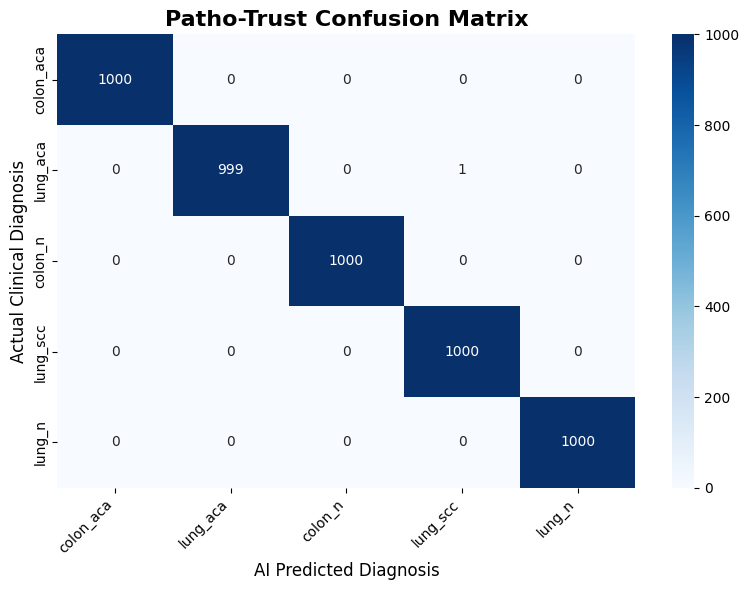

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def evaluate_model(model, val_loader, class_names):
    print("⏳ Running clinical evaluation on Validation Set...")
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            # We don't need mixed precision for simple inference
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Convert class_names dict to an ordered list for classification_report
    ordered_class_names = [class_names[i] for i in range(len(class_names))]

    # 1. Classification Report (Precision, Recall, F1)
    print("\n" + "="*50)
    print("📋 CLINICAL CLASSIFICATION REPORT")
    print("="*50)
    print(classification_report(all_labels, all_preds, target_names=ordered_class_names, digits=4))

    # 2. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ordered_class_names, yticklabels=ordered_class_names)
    plt.title('Patho-Trust Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('Actual Clinical Diagnosis', fontsize=12)
    plt.xlabel('AI Predicted Diagnosis', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


evaluate_model(fast_vit_model, val_loader, class_names)

🔬 Generating Multifocal Grad-CAM++ Heatmaps...


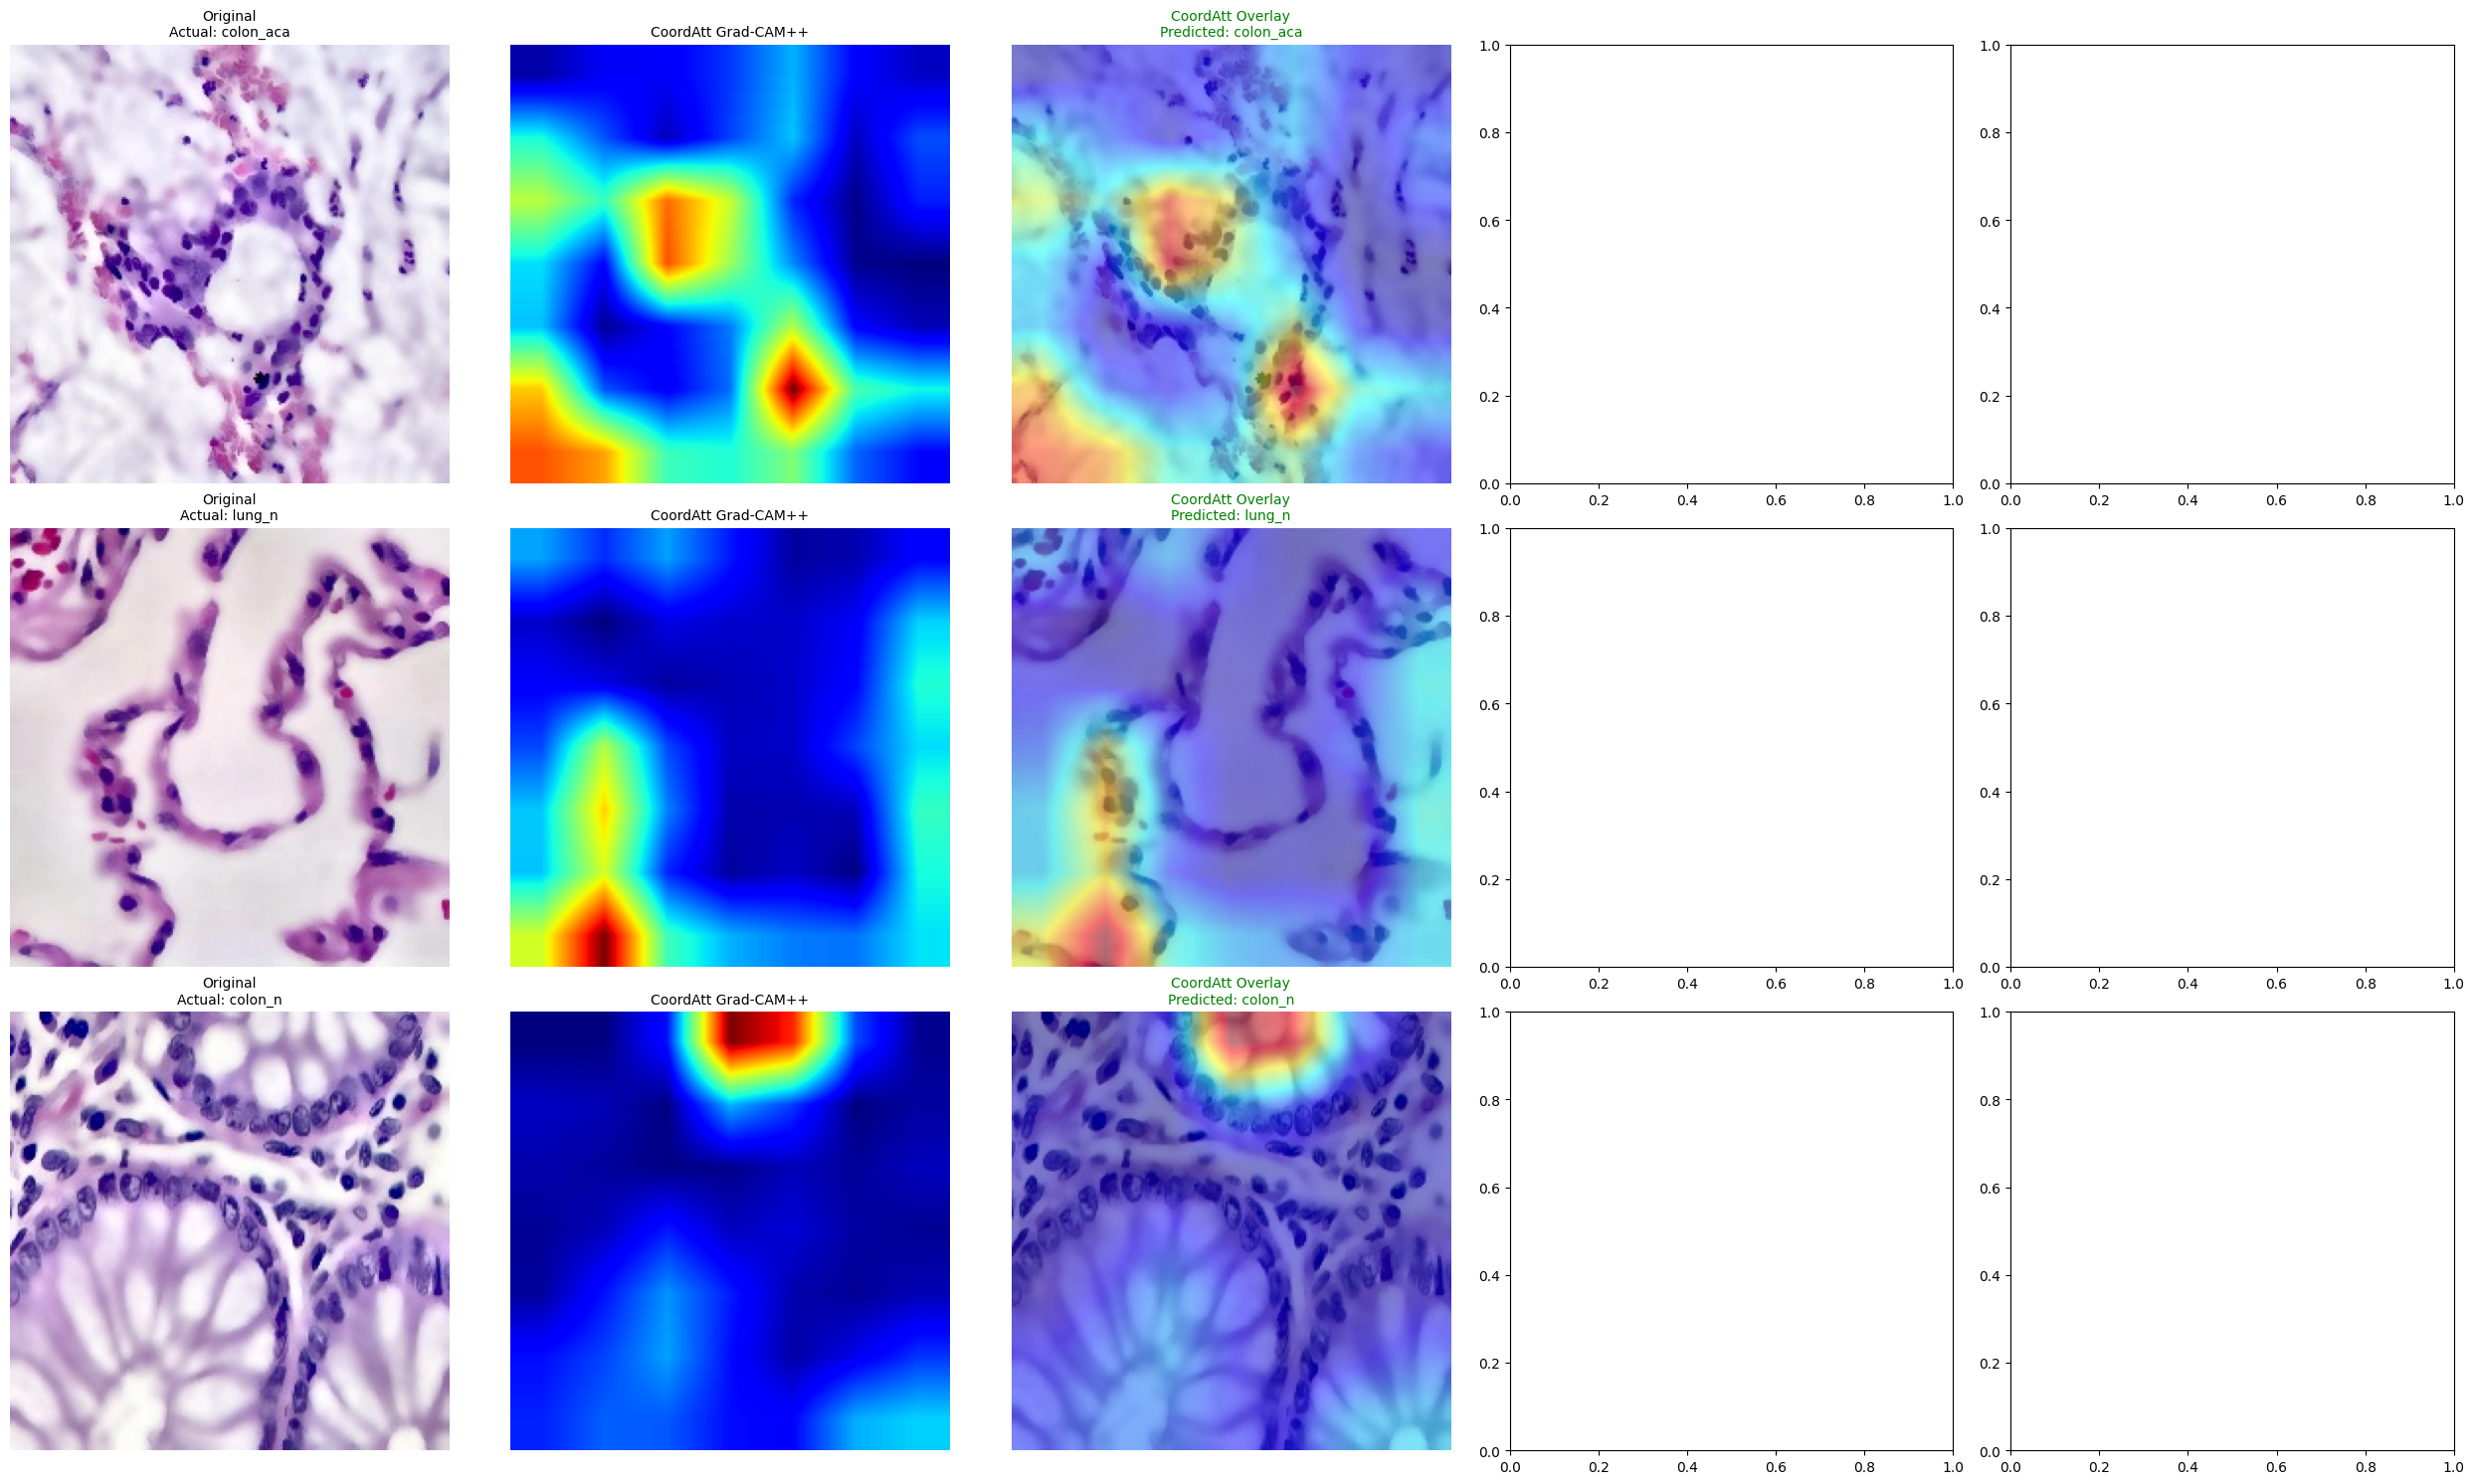

In [ ]:
# CELL: Multifocal Grad-CAM++ Visualizer
!pip install -q grad-cam
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt
import numpy as np
import torch

# Define multiple target layers for multifocal analysis
# We target the output of the Coordinate Attention module and the Projection layer
target_layers = [fast_vit_model.coord_att, fast_vit_model.proj]

# Initialize the Grad-CAM++ object, explicitly setting use_cuda
cam = GradCAMPlusPlus(model=fast_vit_model, target_layers=target_layers)

def visualize_multifocal_heatmap(dataset, model, class_names, num_images=3):
    print("🔬 Generating Multifocal Grad-CAM++ Heatmaps...")
    model.eval()

    indices = np.random.choice(len(dataset), num_images, replace=False)
    # Each image will have: Original, CoordAtt Heatmap, CoordAtt Overlay, Proj Heatmap, Proj Overlay
    fig, axes = plt.subplots(num_images, 5, figsize=(25, 5 * num_images))
    if num_images == 1: # Handle case of single image for consistent indexing
        axes = axes.reshape(1, -1)

    for i, idx in enumerate(indices):
        input_tensor, label_idx = dataset[idx]
        input_tensor = input_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            _, pred_idx = torch.max(output, 1)
            pred_name = class_names[pred_idx.item()]
            actual_name = class_names[label_idx]

        # Generate heatmaps for all specified target layers
        targets = [ClassifierOutputTarget(pred_idx.item())]
        grayscale_cams = cam(input_tensor=input_tensor, targets=targets)

        # Prepare original image for display
        img_display = input_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
        mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)

        # Display Original Image
        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f"Original\nActual: {actual_name}", fontsize=10)
        axes[i, 0].axis('off')

        # Display heatmaps and overlays for each target layer
        for j, (layer_name, grayscale_cam) in enumerate(zip(['CoordAtt', 'Projection'], grayscale_cams)):
            visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

            # Heatmap
            axes[i, 2*j + 1].imshow(grayscale_cam, cmap='jet')
            axes[i, 2*j + 1].set_title(f"{layer_name} Grad-CAM++", fontsize=10)
            axes[i, 2*j + 1].axis('off')

            # Overlay
            axes[i, 2*j + 2].imshow(visualization)
            axes[i, 2*j + 2].set_title(f"{layer_name} Overlay\nPredicted: {pred_name}", fontsize=10,
                                     color='green' if pred_idx.item() == label_idx else 'red')
            axes[i, 2*j + 2].axis('off')

    plt.tight_layout()
    plt.show()

# Run the multifocal visualizer
# Make sure 'val_dataset', 'model', and 'class_names' are defined from previous cells
visualize_multifocal_heatmap(val_dataset, fast_vit_model, class_names, num_images=3)